In [1]:
print("Hello Farhana")

Hello Farhana


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Housing.csv")

In [4]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
df.shape

(545, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [9]:
print("Target Column:")
print("price")

print("\nFeature Columns:")
print(df.columns.drop("price"))

Target Column:
price

Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(545, 13)

In [16]:
df_processed = df.copy()

In [17]:
df_processed = df_processed.replace({
    'yes': 1,
    'no': 0,
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
})

C:\Users\premg\AppData\Local\Temp\ipykernel_16608\3837166865.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_processed = df_processed.replace({


In [18]:
df_processed.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


In [19]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

In [22]:
X = df_processed.drop('price', axis=1)
y = df_processed['price']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (436, 12)
Testing Data: (109, 12)


In [25]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
linear_predictions = linear_model.predict(X_test)

In [27]:
print("LINEAR REGRESSION RESULTS")

print("MAE:",
      mean_absolute_error(y_test, linear_predictions))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, linear_predictions)))

print("R2 Score:",
      r2_score(y_test, linear_predictions))

LINEAR REGRESSION RESULTS
MAE: 979679.6912959903
RMSE: 1331071.4167895105
R2 Score: 0.6494754192267804


In [28]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
rf_predictions = rf_model.predict(X_test)

In [30]:
print("RANDOM FOREST RESULTS")

print("MAE:",
      mean_absolute_error(y_test, rf_predictions))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_predictions)))

print("R2 Score:",
      r2_score(y_test, rf_predictions))


RANDOM FOREST RESULTS
MAE: 1024081.0328746178
RMSE: 1398901.4195830664
R2 Score: 0.612840442148196


In [31]:
comparison = {
    "Linear Regression R2":
        r2_score(y_test, linear_predictions),

    "Random Forest R2":
        r2_score(y_test, rf_predictions)
}

print(comparison)

{'Linear Regression R2': 0.6494754192267804, 'Random Forest R2': 0.612840442148196}


In [32]:
comparison = {
    "Linear Regression R2":
        r2_score(y_test, linear_predictions),

    "Random Forest R2":
        r2_score(y_test, rf_predictions)
}

print(comparison)

{'Linear Regression R2': 0.6494754192267804, 'Random Forest R2': 0.612840442148196}


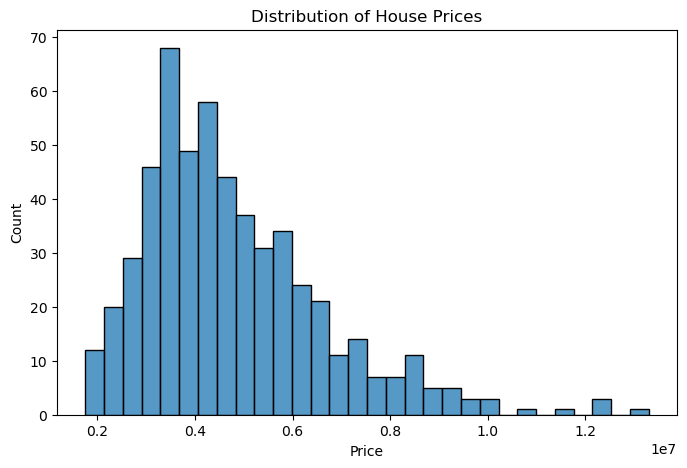

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df_processed['price'], bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.savefig("charts/price_distribution.png")

plt.show()

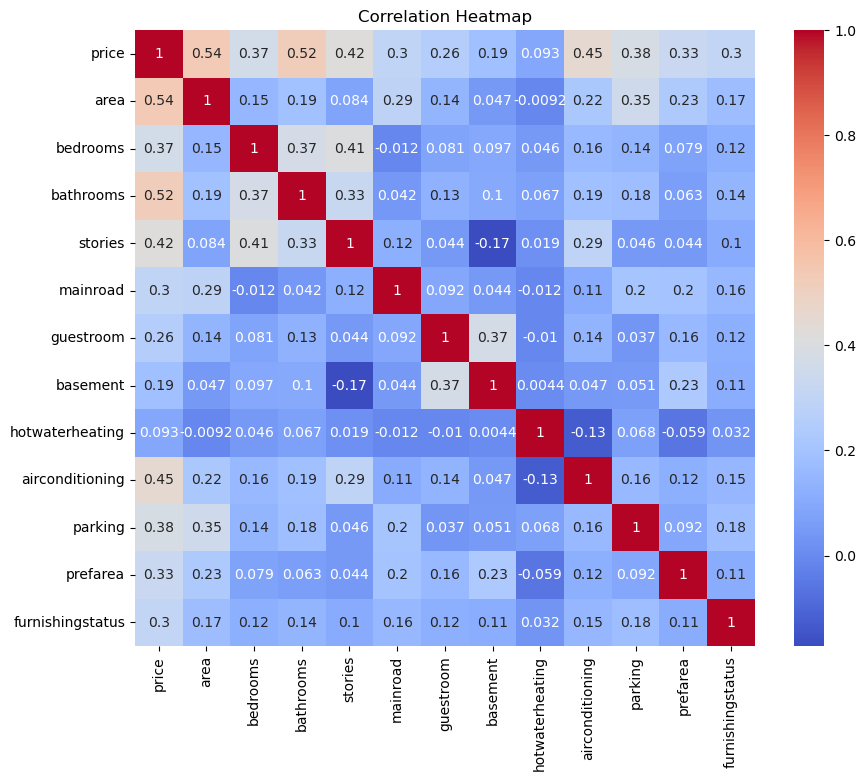

In [34]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_processed.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png")

plt.show()

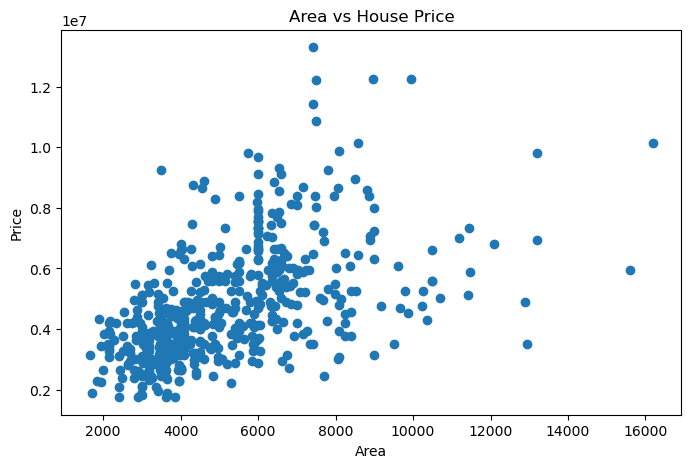

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_processed['area'],
    df_processed['price']
)

plt.xlabel("Area")
plt.ylabel("Price")

plt.title("Area vs House Price")

plt.savefig("charts/area_vs_price.png")

plt.show()

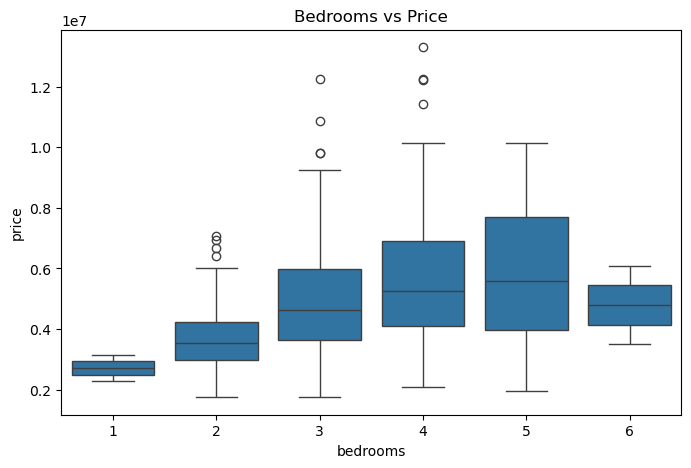

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_processed['bedrooms'],
    y=df_processed['price']
)

plt.title("Bedrooms vs Price")

plt.savefig("charts/bedrooms_vs_price.png")

plt.show()

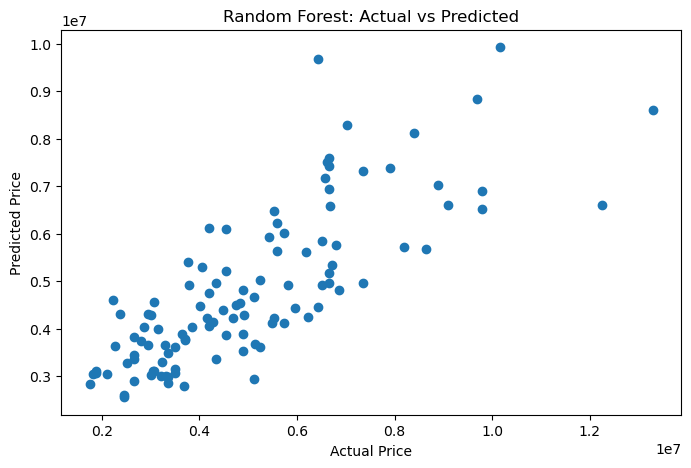

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    rf_predictions
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Random Forest: Actual vs Predicted")

plt.savefig("charts/actual_vs_predicted.png")

plt.show()

In [38]:
print("""
INSIGHTS

1. Area is one of the strongest factors influencing house prices.
2. Houses with more bedrooms and bathrooms generally cost more.
3. Features such as air conditioning and preferred area also affect price.
4. Random Forest performed better than Linear Regression for this dataset.
5. The dataset shows that larger properties tend to command significantly higher prices.

RECOMMENDATION

Real estate businesses should focus on property size,
location preference, and modern amenities when
estimating market value or advising clients.
""")


INSIGHTS

1. Area is one of the strongest factors influencing house prices.
2. Houses with more bedrooms and bathrooms generally cost more.
3. Features such as air conditioning and preferred area also affect price.
4. Random Forest performed better than Linear Regression for this dataset.
5. The dataset shows that larger properties tend to command significantly higher prices.

RECOMMENDATION

Real estate businesses should focus on property size,
location preference, and modern amenities when
estimating market value or advising clients.

